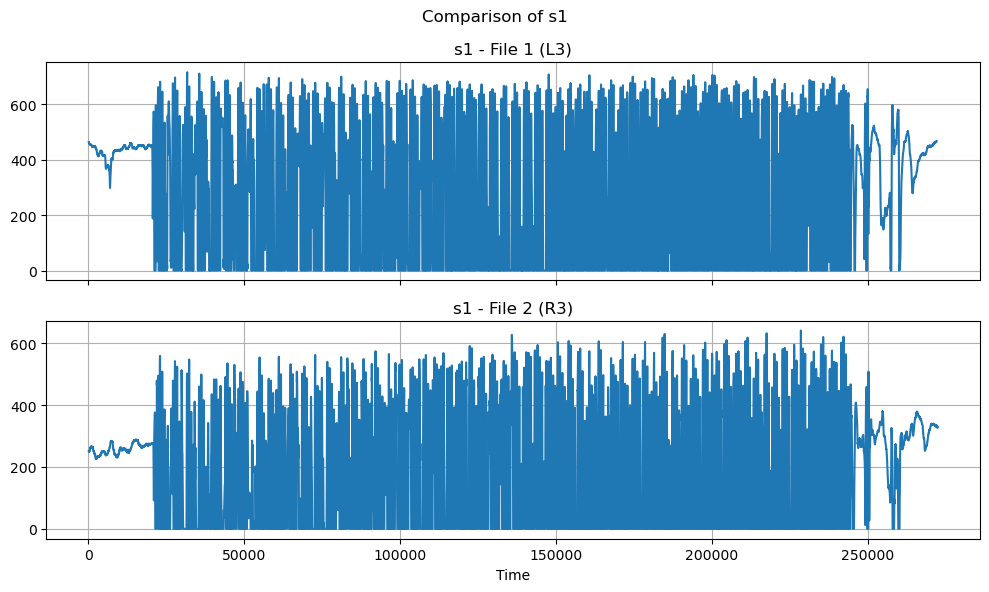

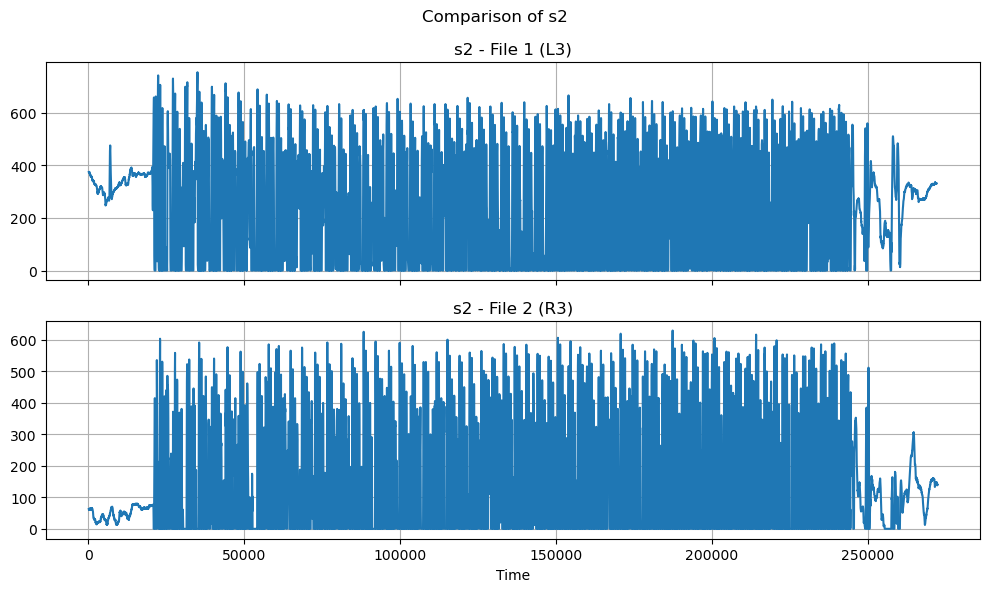

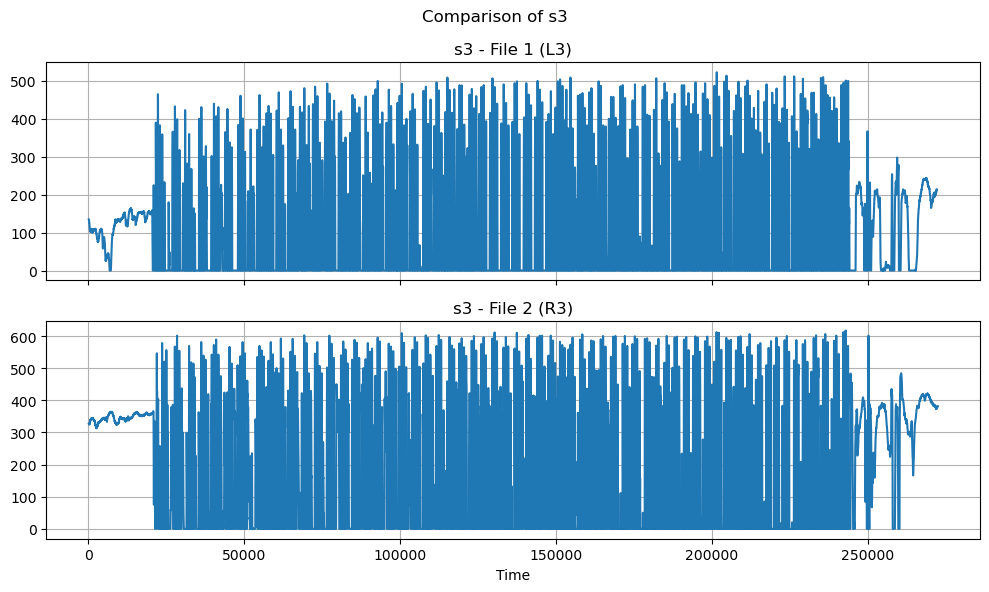

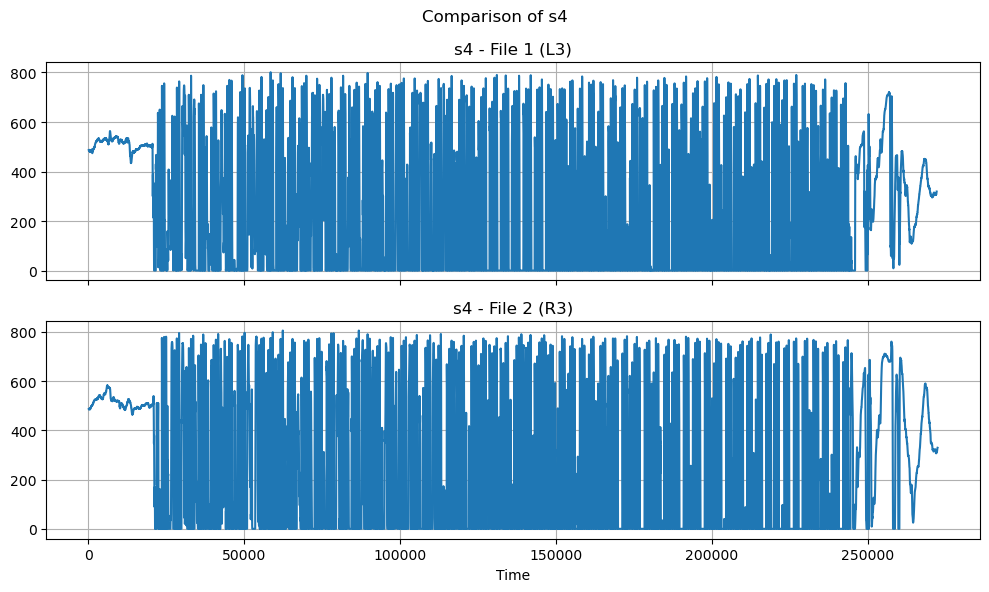

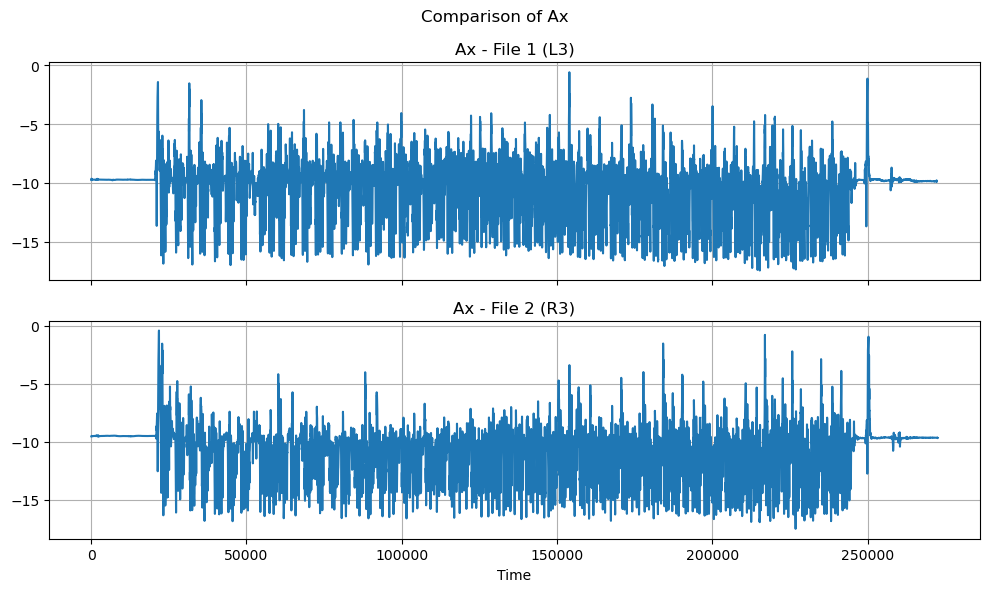

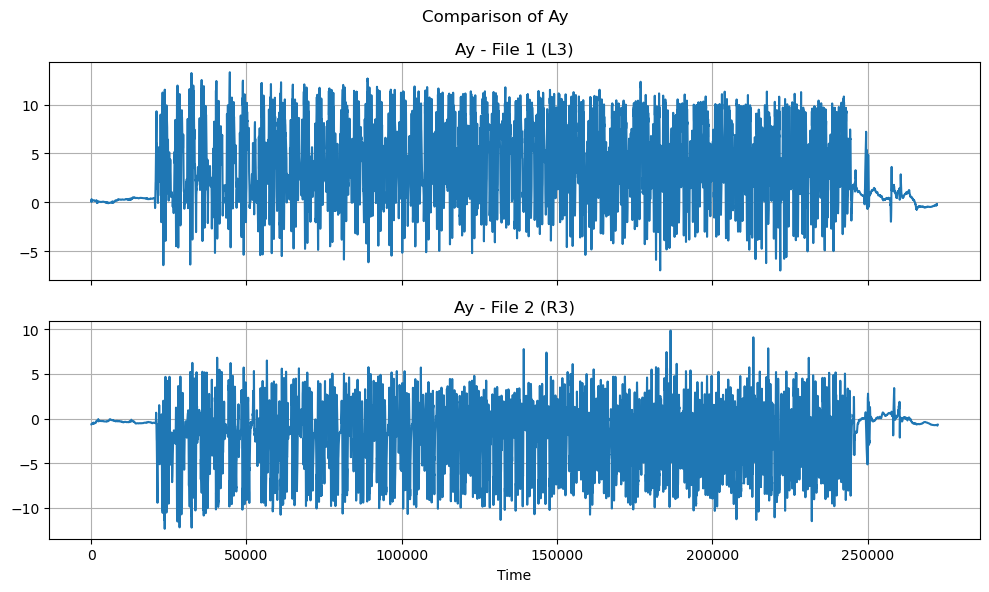

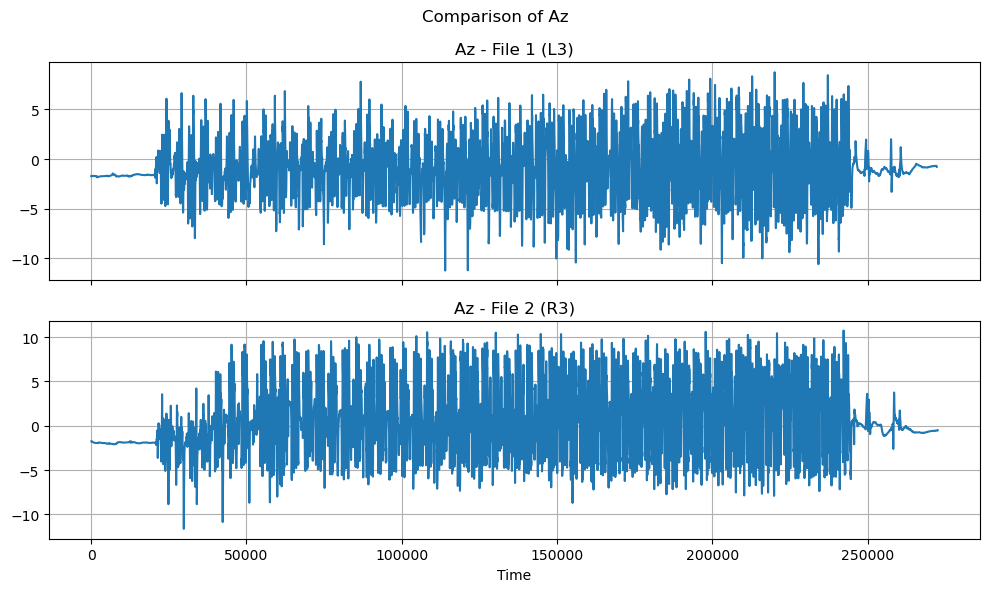

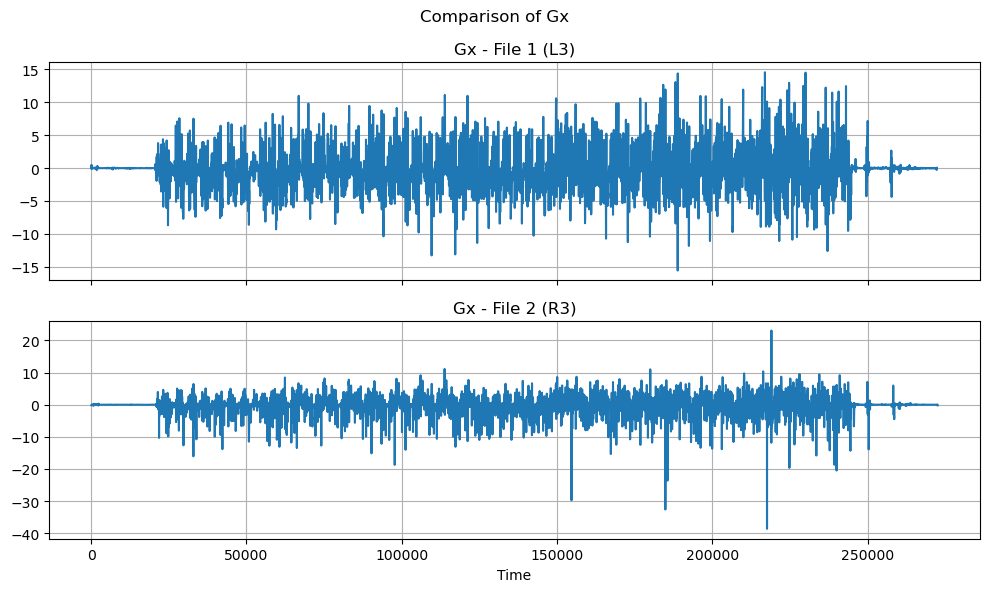

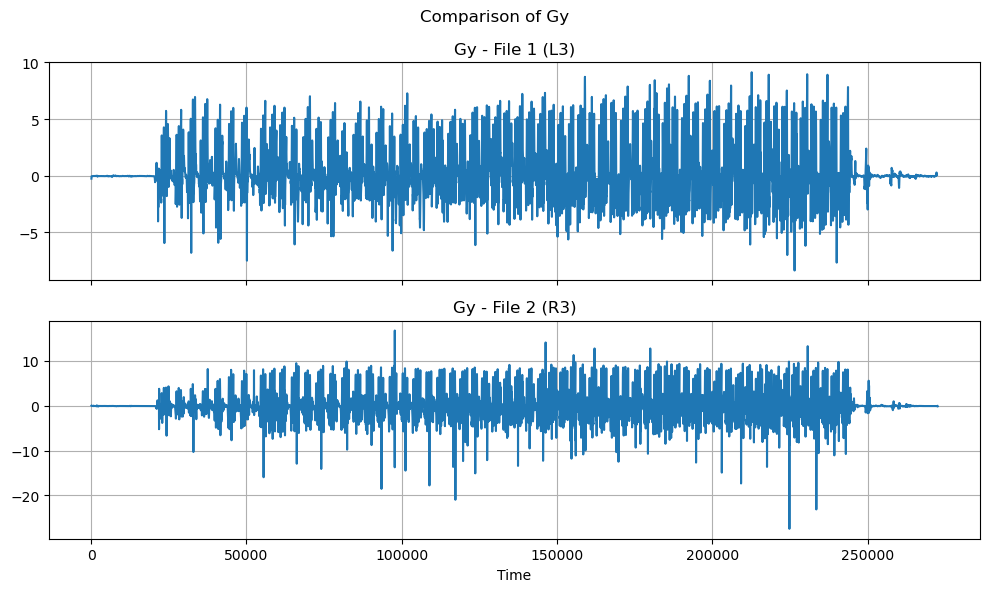

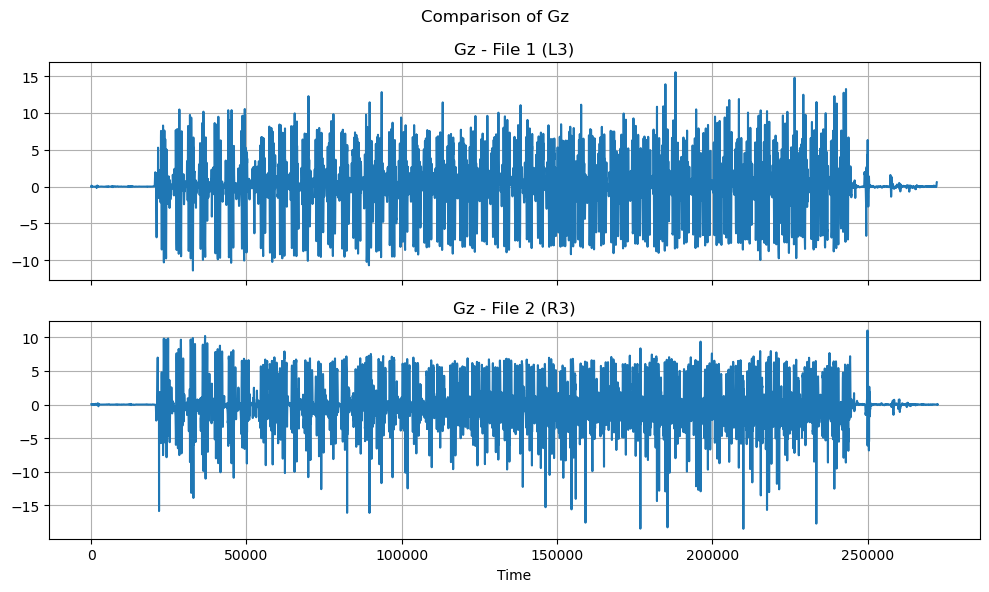

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# LOAD FILES
# =========================
# file1 = r"C:\projects\.venv\HILPCS\FLAMYO\test2\yoyotest3_left.csv"
# file2 = r"C:\projects\.venv\HILPCS\FLAMYO\test2\yoyotest3_right.csv"

file1 = r"C:\projects\.venv\HILPCS\FLAMYO\test\yoyo_left.csv"
file2 = r"C:\projects\.venv\HILPCS\FLAMYO\test\yoyo_right.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# =========================
# COLUMNS TO PLOT
# =========================
cols = ['s1','s2','s3','s4','Ax','Ay','Az','Gx','Gy','Gz']

# =========================
# LOOP THROUGH EACH COLUMN
# =========================
for col in cols:
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    
    # --- File 1 ---
    axes[0].plot(df1['Time'], df1[col])
    axes[0].set_title(f'{col} - File 1 (L3)')
    axes[0].grid()
    
    # --- File 2 ---
    axes[1].plot(df2['Time'], df2[col])
    axes[1].set_title(f'{col} - File 2 (R3)')
    axes[1].grid()
    
    axes[1].set_xlabel('Time')
    
    plt.suptitle(f'Comparison of {col}')
    plt.tight_layout()
    plt.show()

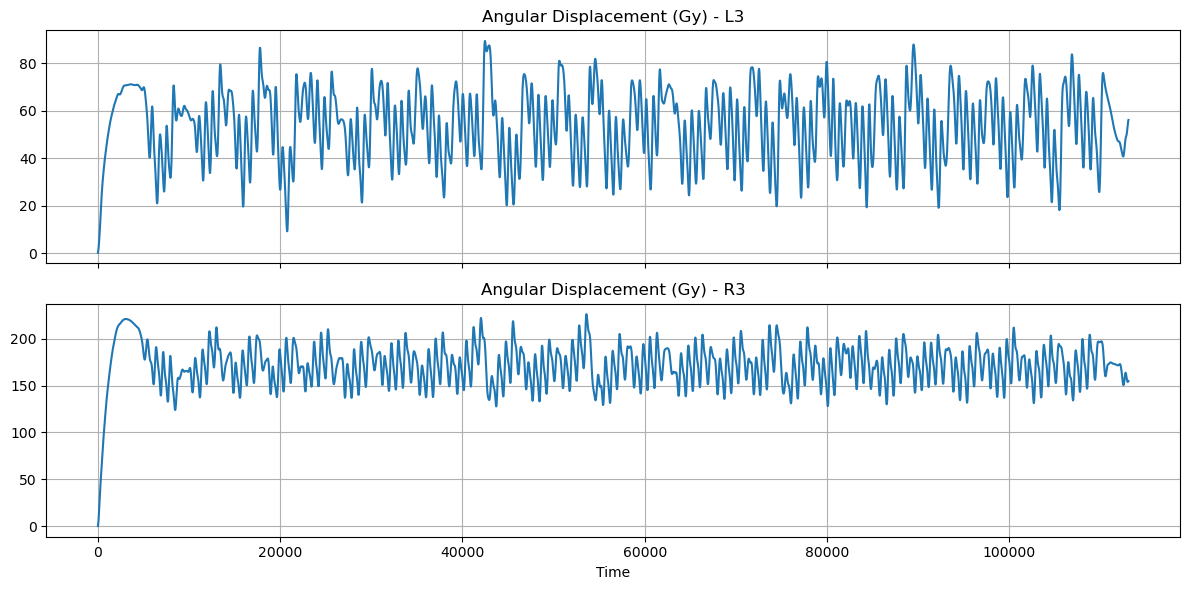

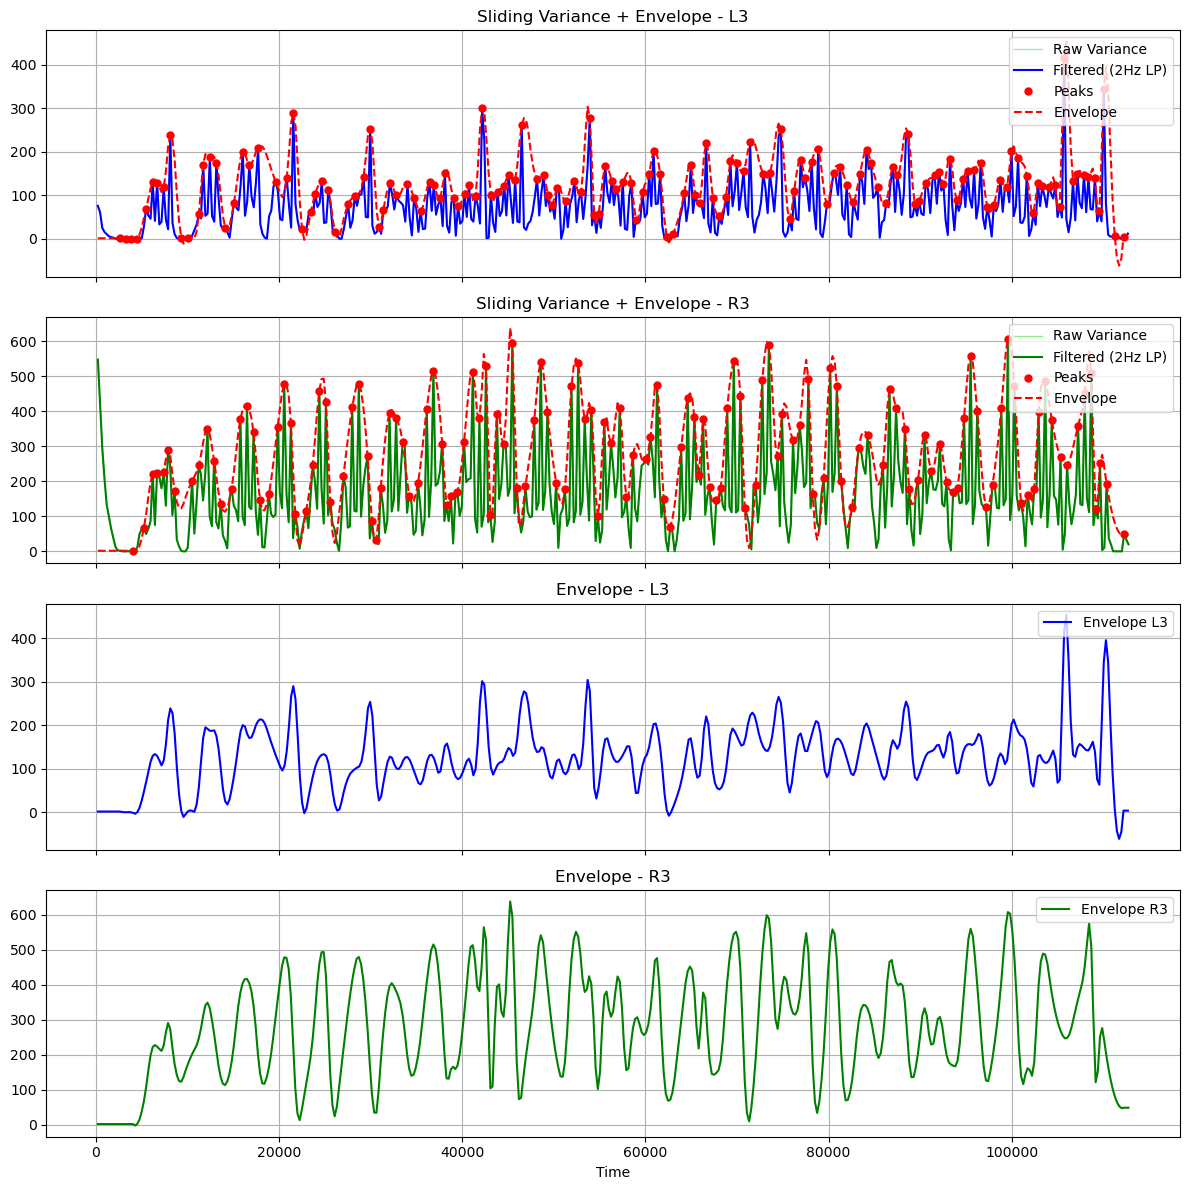

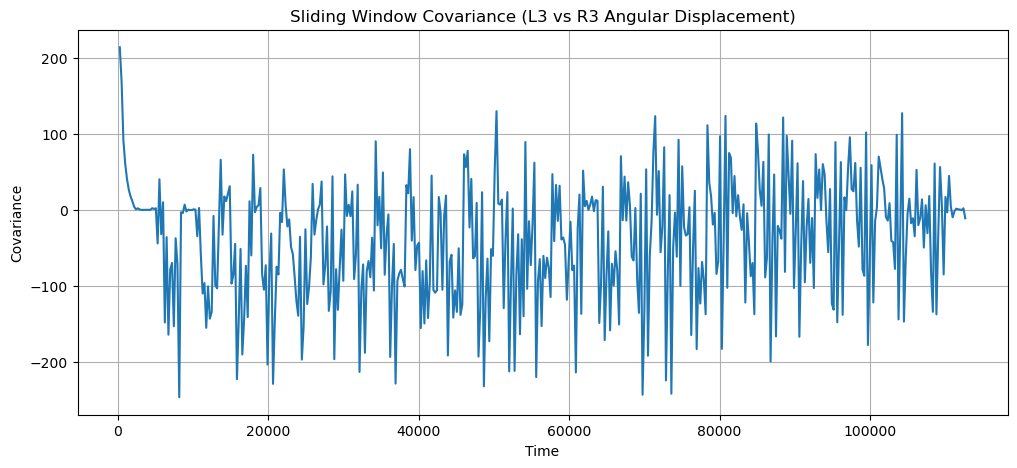

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt,find_peaks

# =========================
# LOAD FILES
# =========================
file1 = r"C:\projects\.venv\HILPCS\FLAMYO\test2\yoyotest5_left_trim.csv"
file2 = r"C:\projects\.venv\HILPCS\FLAMYO\test2\yoyotest5_right_trim.csv"

# file1 = r"C:\projects\.venv\HILPCS\FLAMYO\test\yoyo_left.csv"
# file2 = r"C:\projects\.venv\HILPCS\FLAMYO\test\yoyo_right.csv"

# file1 = r"C:\projects\.venv\HILPCS\FLAMYO\L3.csv"
# file2 = r"C:\projects\.venv\HILPCS\FLAMYO\R3.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# =========================
# SAMPLING INFO
# =========================
fs = 43
dt = 1/fs

# =========================
# BANDPASS FILTER
# =========================
def bandpass(data, low=0.5, high=3, fs=43, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, data)

# =========================
# PROCESS FUNCTION
# =========================
def process(df):
    Gy = df['Gy'].values
    
    # 1. Filter
    Gy_f = bandpass(Gy, 0.1, 3, fs)
    
    # 2. Integrate (rad → deg)
    angle = np.cumsum(Gy_f * dt) * (180/np.pi)
    
    return Gy_f, angle

# Process both
Gy1_f, angle1 = process(df1)
Gy2_f, angle2 = process(df2)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# --- File 1 ---
axes[0].plot(df1['Time'], angle1)
axes[0].set_title('Angular Displacement (Gy) - L3')
axes[0].grid()

# --- File 2 ---
axes[1].plot(df2['Time'], angle2)
axes[1].set_title('Angular Displacement (Gy) - R3')
axes[1].grid()

axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()



from scipy.interpolate import interp1d

def sliding_variance(signal, window_size=40, step=20):
    variances = []
    centers = []
    
    for start in range(0, len(signal) - window_size + 1, step):
        window = signal[start:start + window_size]
        variances.append(np.var(window))
        centers.append(start + window_size // 2)
    
    return np.array(variances), np.array(centers)

# Compute for both signals
var1, idx1 = sliding_variance(angle1, 20, 10)
var2, idx2 = sliding_variance(angle2, 20, 10)

# Convert indices to time
time1 = df1['Time'].values[idx1]
time2 = df2['Time'].values[idx2]



var1_filt = var1
var2_filt = var2

# ===== PEAK-BASED ENVELOPE =====
def peak_envelope(signal, time, min_dist_sec=0.5):

    fs_local = 1 / np.mean(np.diff(time))
    min_dist_samples = max(1, int(min_dist_sec * fs_local))

    peaks, _ = find_peaks(signal, distance=min_dist_samples)

    if len(peaks) < 2:
        # fallback — flat envelope at max
        return np.full_like(signal, np.max(signal))

    # cubic interpolation through peaks
    interp_func = interp1d(time[peaks], signal[peaks],
                           kind='quadratic',
                           bounds_error=False,
                           fill_value=(signal[peaks[0]], signal[peaks[-1]]))

    envelope = interp_func(time)

    return envelope, peaks

env1, peaks1_env = peak_envelope(var1_filt, time1, min_dist_sec=0.5)
env2, peaks2_env = peak_envelope(var2_filt, time2, min_dist_sec=0.5)


fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# --- File 1 ---
axes[0].plot(time1, var1,       'lightblue',  linewidth=1,   label='Raw Variance')
axes[0].plot(time1, var1_filt,  'b',          linewidth=1.5, label='Filtered (2Hz LP)')
axes[0].plot(time1[peaks1_env], var1_filt[peaks1_env], 'ro', markersize=5, label='Peaks')
axes[0].plot(time1, env1,       'r--',        linewidth=1.5, label='Envelope')
axes[0].set_title('Sliding Variance + Envelope - L3')
axes[0].legend(loc='upper right')
axes[0].grid()

# --- File 2 ---
axes[1].plot(time2, var2,       'lightgreen', linewidth=1,   label='Raw Variance')
axes[1].plot(time2, var2_filt,  'g',          linewidth=1.5, label='Filtered (2Hz LP)')
axes[1].plot(time2[peaks2_env], var2_filt[peaks2_env], 'ro', markersize=5, label='Peaks')
axes[1].plot(time2, env2,       'r--',        linewidth=1.5, label='Envelope')
axes[1].set_title('Sliding Variance + Envelope - R3')
axes[1].legend(loc='upper right')
axes[1].grid()

# --- Envelopes only ---
axes[2].plot(time1, env1, 'b',  linewidth=1.5, label='Envelope L3')
axes[2].set_title('Envelope - L3')
axes[2].legend(loc='upper right')
axes[2].grid()

axes[3].plot(time2, env2, 'g',  linewidth=1.5, label='Envelope R3')
axes[3].set_title('Envelope - R3')
axes[3].legend(loc='upper right')
axes[3].grid()

axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()




# =========================
# SLIDING WINDOW COVARIANCE
# =========================
def sliding_covariance(sig1, sig2, window_size=20, step=10):
    covs = []
    centers = []
    
    for start in range(0, len(sig1) - window_size + 1, step):
        w1 = sig1[start:start + window_size]
        w2 = sig2[start:start + window_size]
        
        cov = np.cov(w1, w2)[0,1]
        covs.append(cov)
        
        centers.append(start + window_size // 2)
    
    return np.array(covs), np.array(centers)

# Compute covariance
cov_vals, idx = sliding_covariance(angle1, angle2, 20, 10)

# Map to time
time_cov = df1['Time'].values[idx]
plt.figure(figsize=(12,5))

plt.plot(time_cov, cov_vals)
plt.title('Sliding Window Covariance (L3 vs R3 Angular Displacement)')
plt.xlabel('Time')
plt.ylabel('Covariance')
plt.grid()

plt.show()

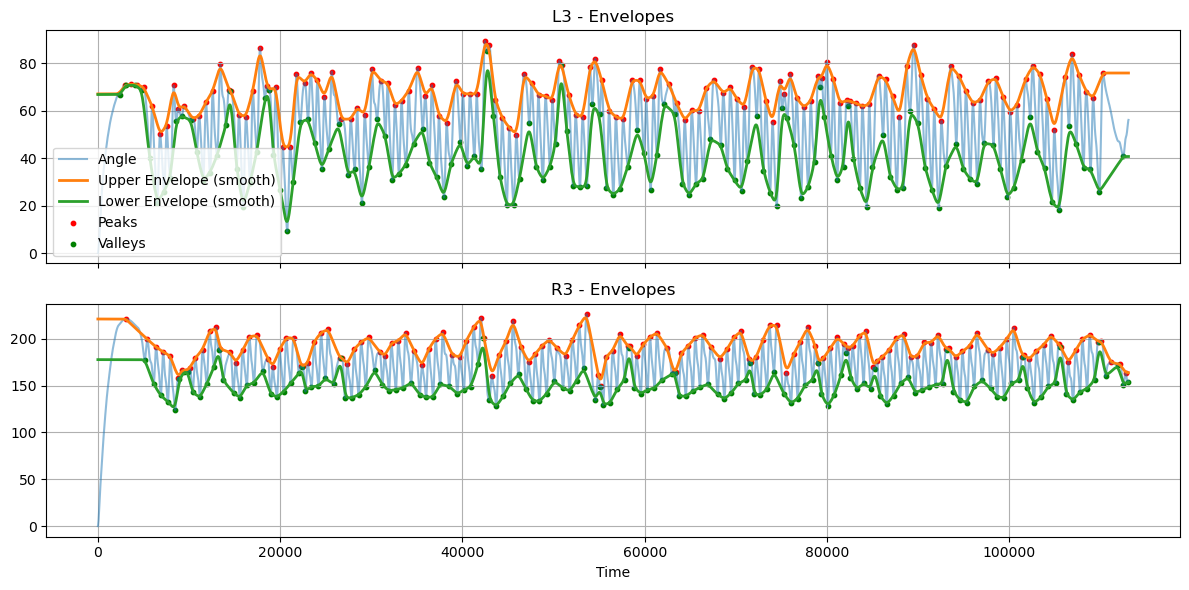

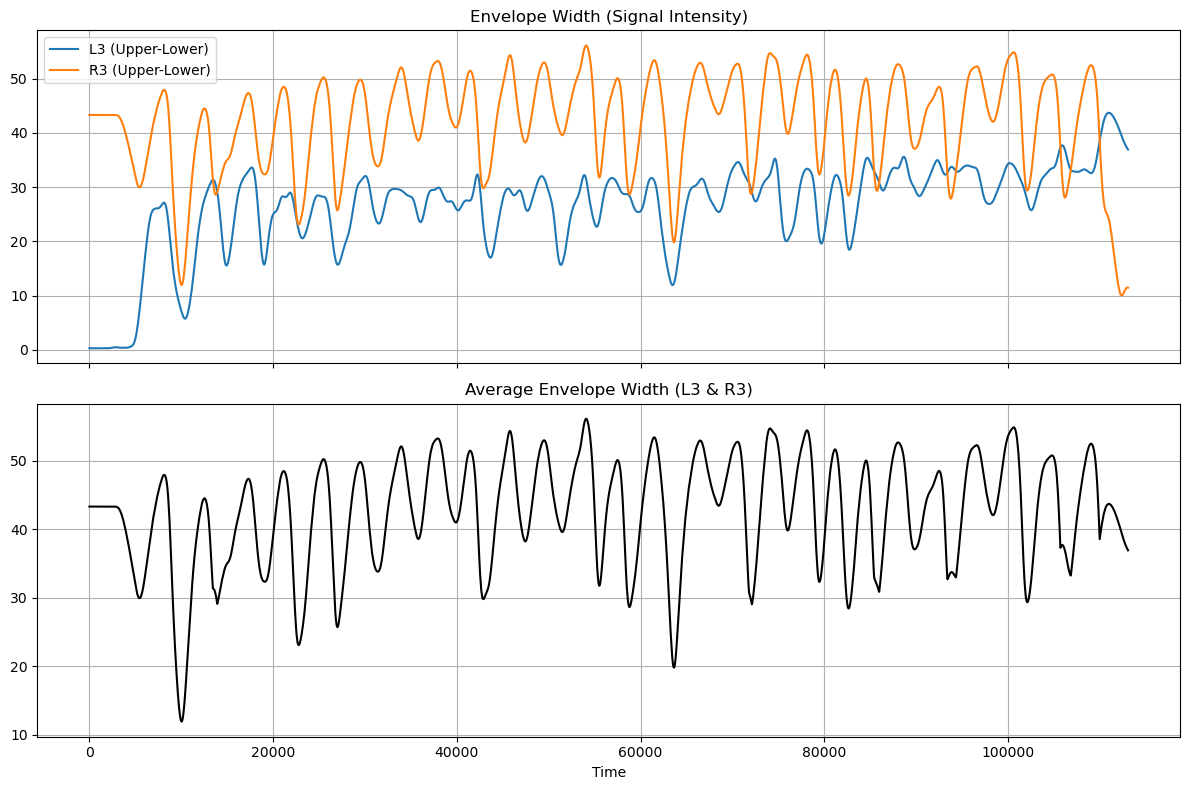

In [7]:

# =========================
# ENVELOPE FUNCTION
# =========================
from scipy.signal import find_peaks, savgol_filter
from scipy.interpolate import CubicSpline
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import numpy as np

def compute_envelopes(signal, sigma=8):
    
    x = np.arange(len(signal))
    
    # --- Peaks (upper envelope)
    peaks, _ = find_peaks(signal)
    
    # --- Valleys (lower envelope)
    valleys, _ = find_peaks(-signal)
    
    # --- Initialize envelopes
    upper_env = np.full_like(signal, np.nan, dtype=float)
    lower_env = np.full_like(signal, np.nan, dtype=float)
    
    upper_env[peaks] = signal[peaks]
    lower_env[valleys] = signal[valleys]
    
    # --- Fill NaNs using interpolation (needed for filtering)
    def fill_nan(data):
        valid = ~np.isnan(data)
        if np.sum(valid) < 2:
            return data
        return np.interp(x, x[valid], data[valid])
    
    upper_filled = fill_nan(upper_env)
    lower_filled = fill_nan(lower_env)
    
    # --- Gaussian smoothing
    upper_smooth = gaussian_filter1d(upper_filled, sigma=sigma)
    lower_smooth = gaussian_filter1d(lower_filled, sigma=sigma)
    
    return upper_smooth, lower_smooth, peaks, valleys


def kalman_filter_1d(signal, Q=1e-4, R=1e-2):
    n = len(signal)
    
    x_est = np.zeros(n)
    P = np.zeros(n)
    
    # Initialize
    x_est[0] = signal[0]
    P[0] = 1.0
    
    for k in range(1, n):
        # Prediction
        x_pred = x_est[k-1]
        P_pred = P[k-1] + Q
        
        # Update
        K = P_pred / (P_pred + R)
        x_est[k] = x_pred + K * (signal[k] - x_pred)
        P[k] = (1 - K) * P_pred
    
    return x_est



# =========================
# PROCESS BOTH SIGNALS
# =========================
upper1, lower1, peaks1, valleys1 = compute_envelopes(angle1)
upper2, lower2, peaks2, valleys2 = compute_envelopes(angle2)

fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# --- L3 ---
axes[0].plot(df1['Time'], angle1, label='Angle', alpha=0.5)
axes[0].plot(df1['Time'], upper1, label='Upper Envelope (smooth)', linewidth=2)
axes[0].plot(df1['Time'], lower1, label='Lower Envelope (smooth)', linewidth=2)
axes[0].scatter(df1['Time'].values[peaks1], angle1[peaks1], color='red', s=10, label='Peaks')
axes[0].scatter(df1['Time'].values[valleys1], angle1[valleys1], color='green', s=10, label='Valleys')

axes[0].set_title('L3 - Envelopes')
axes[0].legend()
axes[0].grid()

# --- R3 ---
axes[1].plot(df2['Time'], angle2, label='Angle', alpha=0.5)
axes[1].plot(df2['Time'], upper2, label='Upper Envelope (smooth)', linewidth=2)
axes[1].plot(df2['Time'], lower2, label='Lower Envelope (smooth)', linewidth=2)
axes[1].scatter(df2['Time'].values[peaks2], angle2[peaks2], color='red', s=10)
axes[1].scatter(df2['Time'].values[valleys2], angle2[valleys2], color='green', s=10)

axes[1].set_title('R3 - Envelopes')
axes[1].grid()

axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

env_diff1 = upper1 - lower1
env_diff2 = upper2 - lower2

env_diff_kalman1 = kalman_filter_1d(env_diff1, Q=1e-5, R=1e-2)
env_diff_kalman2 = kalman_filter_1d(env_diff2, Q=1e-5, R=1e-2)

# Trim to same length
min_len = min(len(env_diff1), len(env_diff2))

env_diff1 = env_diff_kalman1[:min_len]
env_diff2 = env_diff_kalman2 [:min_len]

# ✅ Correct average (element-wise)
avg_env = np.maximum(env_diff1, env_diff2)             # vchanges from min to mean

# Use same time base
time = df1['Time'].values[:min_len]

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# --- Envelope width ---
axes[0].plot(time, env_diff1, label='L3 (Upper-Lower)')
axes[0].plot(time, env_diff2, label='R3 (Upper-Lower)')
axes[0].set_title('Envelope Width (Signal Intensity)')
axes[0].legend()
axes[0].grid()

# --- Average envelope ---
axes[1].plot(time, avg_env, color='black')
axes[1].set_title('Average Envelope Width (L3 & R3)')
axes[1].grid()
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()



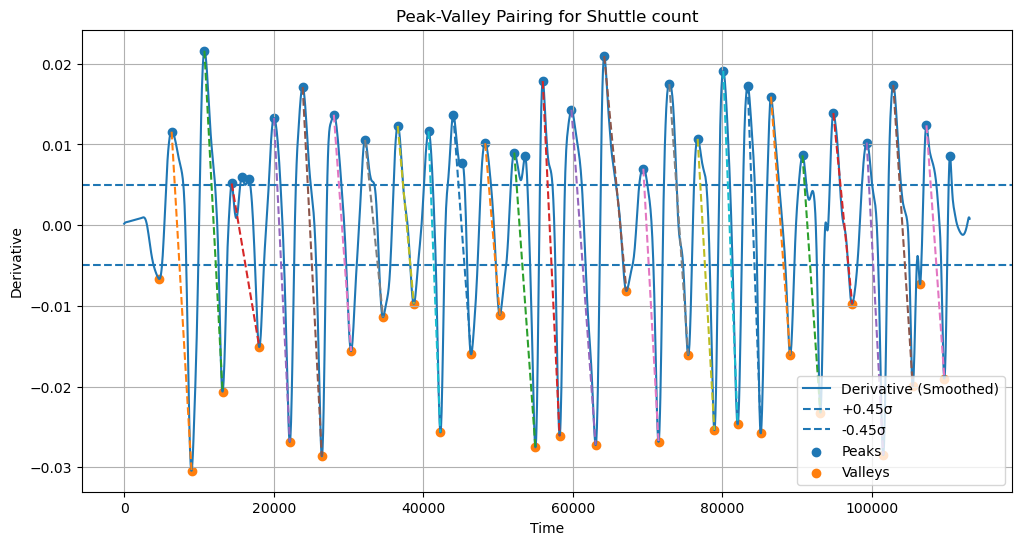

Number of pairs found: 26


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, savgol_filter, find_peaks
# =========================
# SAMPLING
# =========================
fs = 43

# =========================
# BANDPASS FILTER
# =========================
def bandpass(data, low=0.1, high=1, fs=43, order=4):
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, data)

# =========================
# APPLY FILTERS
# =========================

# 1. Bandpass
avg_env_bp = bandpass(avg_env, 0.1, 2, fs)

# 2. Savitzky-Golay smoothing
# window must be odd → 21 is fine
avg_env_smooth = savgol_filter(avg_env, window_length=21, polyorder=2)
# =========================
# INPUT
# =========================
signal = avg_env_bp
t = time   # your time array

# =========================
# SAMPLING
# =========================
dt = np.mean(np.diff(t))   # assume seconds
fs = 1 / dt


signal_filt = signal
# =========================
# SAVITZKY-GOLAY SMOOTHING
# =========================
signal_smooth = savgol_filter(signal_filt, window_length=51, polyorder=3)

# =========================
# FIRST DERIVATIVE
# =========================
d_signal = np.diff(signal_smooth) / dt
t_deriv = t[:-1]

# =========================
# TRIANGULAR SMOOTHING
# =========================
win = 21
tri_win = np.bartlett(win)
tri_win = tri_win / np.sum(tri_win)

d_signal_smooth = np.convolve(d_signal, tri_win, mode='same')

# =========================
# THRESHOLDS
# =========================
sigma = np.std(d_signal_smooth)

pos_th = 0.45 * sigma
neg_th = -0.45 * sigma

# =========================
# PEAKS & VALLEYS
# =========================
# Peaks above +threshold
peaks, _ = find_peaks(d_signal_smooth, height=pos_th)

# Valleys below -threshold
valleys, _ = find_peaks(-d_signal_smooth, height=pos_th)

# Convert indices → time
locs_p = t_deriv[peaks]
locs_v = t_deriv[valleys]

# =========================
# PAIRING LOGIC
# =========================
pairs_p = []
pairs_v = []

i, j = 0, 0

while i < len(locs_p) and j < len(locs_v):
    
    if locs_p[i] < locs_v[j]:
        
        # find peaks before this valley
        valid_peaks = locs_p[i:][locs_p[i:] < locs_v[j]]
        
        if len(valid_peaks) == 0:
            i += 1
            continue
        
        selected_peak = valid_peaks[0]
        
        pairs_p.append(selected_peak)
        pairs_v.append(locs_v[j])
        
        # move i to first peak after valley
        next_peaks = np.where(locs_p > locs_v[j])[0]
        if len(next_peaks) == 0:
            break
        
        i = next_peaks[0]
        j += 1
    
    else:
        j += 1

pairs_p = np.array(pairs_p)
pairs_v = np.array(pairs_v)

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,6))

plt.plot(t_deriv, d_signal_smooth, label='Derivative (Smoothed)')

# thresholds
plt.axhline(pos_th, linestyle='--', label='+0.45σ')
plt.axhline(neg_th, linestyle='--', label='-0.45σ')

# peaks & valleys
plt.scatter(locs_p, d_signal_smooth[peaks], label='Peaks')
plt.scatter(locs_v, d_signal_smooth[valleys], label='Valleys')

# paired points
for k in range(len(pairs_p)):
    plt.plot([pairs_p[k], pairs_v[k]],
             [np.interp(pairs_p[k], t_deriv, d_signal_smooth),
              np.interp(pairs_v[k], t_deriv, d_signal_smooth)],
             linestyle='--')

plt.title('Peak-Valley Pairing for Shuttle count')
plt.xlabel('Time')
plt.ylabel('Derivative')
plt.legend()
plt.grid()

plt.show()

print("Number of pairs found:", len(pairs_p))